# Polymarket Buyer Risk Scoring Using Orderbook Anomaly Detection

This notebook builds a Spark-based MVP pipeline for Polymarket orderbook data.

## Project idea

The goal is to create a **buyer-risk screening tool** for prediction markets. The notebook looks for **manipulation-like orderbook signals** that can make a market risky for buyers, such as:

- wide or unstable bid-ask spreads
- sudden price movement
- sudden activity spikes
- large orderbook changes
- one-sided buy/sell pressure
- liquidity stress

## Important framing

The output is a **Buyer Risk Score**.

A high score means:

> This market-window showed several abnormal orderbook signals, not necessarily outright fraud.

## Quick Glossary of Core Risk Concepts

| Concept | Meaning in this notebook |
|---|---|
| `best_bid` | Highest price currently offered by buyers |
| `best_ask` | Lowest price currently offered by sellers |
| `spread` | Difference between best ask and best bid |
| `mid_price` | Approximate market price, usually halfway between bid and ask |
| `change_size` | Size of an orderbook update |
| `change_side` | Whether the update happened on the BUY or SELL side |
| `tick_count` | Number of orderbook updates in a time window |
| `price_range` | Difference between highest and lowest mid-price in a window |
| `imbalance_score` | How one-sided the BUY/SELL pressure is |
| `anomaly_count` | Number of abnormality rules triggered |
| `risk_score` | Weighted 0–100 buyer-risk score |

The risk score is intentionally explainable. Each point comes from a visible flag, not from a black-box model.


# Integrated Report: Polymarket Buyer Risk Scoring Using Orderbook Anomaly Detection

## Executive Summary

This project builds a Spark-based pipeline that analyzes Polymarket tick-level orderbook data and converts raw market activity into a buyer-focused risk ranking. The notebook flags markets that show **manipulation-like or abnormal orderbook behavior** based on observable signals such as bid-ask spread movement, price movement, orderbook activity, large order changes, buy/sell pressure, and liquidity stress.

The resulting output is a **Buyer Risk Score**, scaled from 0 to 100. Higher scores indicate that a market-window triggered more abnormal risk signals. The score is designed as a screening tool: it helps identify markets that may deserve closer review before a user treats market prices as reliable event probabilities.

The project is implemented as a **Minimum Viable Product (MVP)**. It prioritizes explainability, Spark scalability, and restartability through saved Parquet checkpoints. Because Spark sessions can die during large computations, the notebook stores key processed tables so that later runs can resume without repeating the most expensive raw orderbook aggregation.

## Main Deliverables

1. A Spark pipeline that loads Polymarket labels and orderbook data.
2. A resumable checkpoint structure for processed intermediate tables.
3. Market-window feature engineering using 1-hour windows.
4. Rule-based anomaly flags for abnormal orderbook behavior.
5. A 0–100 Buyer Risk Score.
6. Market-level risk rankings.
7. Category-level risk summaries using keyword-based topic classification.
8. Explainability fields showing the main risk driver for each flagged market.

## Important Framing

This notebook should be interpreted as a **risk screening system**, not a fraud accusation system. A high Buyer Risk Score means the market displayed abnormal orderbook behavior within the analyzed period. It does not establish trader intent, legal manipulation, spoofing, wash trading, or fraud.

## Problem Statement

Prediction markets such as Polymarket express market-implied probabilities for real-world events. Users may treat these prices as signals of expected outcomes. However, some markets can be thin, unstable, or affected by short bursts of abnormal orderbook activity. These conditions can expose buyers to poor execution, misleading prices, or increased uncertainty.

The project addresses the following question:

> Which Polymarket markets show abnormal orderbook behavior that may create buyer risk?

A secondary question is:

> Are abnormal signals concentrated in specific market topics, such as politics, crypto, sports, technology, economy, or entertainment?

## Dataset and Scope

The notebook uses Polymarket Parquet data consisting mainly of:

| Data Source | Role in the Pipeline |
|---|---|
| `labels/market_targets.parquet` | Market metadata such as market question, volume, liquidity, closed status, YES/NO token IDs, and target where available. |
| `orderbook/orderbook_2026-03-06.parquet` | Tick-level orderbook activity including timestamps, market ID, bid/ask prices, spread, mid-price, change size, change side, and token ID. |

The available orderbook fields make it possible to compute spread behavior, price behavior, activity intensity, buy/sell pressure, and liquidity stress. However, the MVP does not use full orderbook depth beyond the fields available in the selected file. This means deeper market-manipulation patterns such as confirmed layering or spoofing can only be approximated indirectly, not proven.

## Methodology Overview

The notebook follows a staged Spark pipeline:

```text
Load raw data
→ validate schema and join keys
→ keep labeled/interpretable markets
→ clean timestamps and categories
→ filter active markets
→ create 1-hour market windows
→ engineer orderbook features
→ create anomaly flags
→ calculate Buyer Risk Score
→ aggregate to market level
→ classify topics using keywords
→ summarize by market and category
→ save final outputs and checkpoints
```

### NOTE: Why 1-Hour Market Windows?

The raw data is tick-level, which is too granular for direct interpretation. The notebook groups activity into 1-hour windows so each row represents one market during one hour. This provides a balance: short enough to catch abnormal bursts, but not so short that the results become overly noisy.

## Buyer Risk Score Design

The Buyer Risk Score is an explainable, rule-based score ranging from 0 to 100. It combines multiple abnormal orderbook signals into one screening indicator.

### Feature Groups

| Feature Group | Example Metrics | Buyer-Risk Logic |
|---|---|---|
| Spread behavior | Average spread, maximum spread, spread volatility | Wide or unstable spreads mean buyers may face worse execution and weaker liquidity. |
| Price behavior | Mid-price range and volatility proxy | Sharp price changes can indicate unstable market probability or abnormal trading bursts. |
| Activity behavior | Tick count and total change size | Sudden spikes in orderbook updates may indicate unusual attention or trading pressure. |
| Order size behavior | Maximum change size and total change size | Very large orderbook changes may signal abnormal pressure or liquidity movement. |
| Buy/sell pressure | Buy pressure, sell pressure, imbalance score | Extreme one-sided pressure may indicate directional crowding or abnormal orderbook behavior. |
| Liquidity stress | Wide spread combined with low activity | Buyers may have difficulty entering or exiting at fair prices. |

### Anomaly Flags

The notebook first converts numeric features into binary flags. Each flag equals 1 if a market-window is abnormal by the selected threshold and 0 otherwise.

| Flag | Meaning |
|---|---|
| `spread_spike_flag` | Average spread is unusually high. |
| `spread_instability_flag` | Spread movement is unusually unstable. |
| `price_jump_flag` | Mid-price movement within the window is unusually large. |
| `activity_spike_flag` | Tick activity is unusually high. |
| `large_order_flag` | Maximum orderbook change size is unusually large. |
| `high_volume_change_flag` | Total orderbook change size is unusually high. |
| `imbalance_flag` | Buy-side or sell-side pressure dominates the window. |
| `liquidity_stress_flag` | Spread is high while activity is low. |

### Score Formula

The MVP Buyer Risk Score is calculated as:

```text
Buyer Risk Score =
  20 × spread_spike_flag
+ 15 × spread_instability_flag
+ 20 × price_jump_flag
+ 15 × activity_spike_flag
+ 10 × large_order_flag
+ 10 × high_volume_change_flag
+  5 × imbalance_flag
+  5 × liquidity_stress_flag
```

The maximum score is 100.

### Why These Weights?

The weights are not copied from a single academic paper. They are an explainable MVP design based on the relative buyer impact of each signal.

| Component | Weight | Reason |
|---|---:|---|
| Spread spike | 20 | Directly affects buyer execution cost and liquidity quality. |
| Price jump | 20 | Captures large probability movement and potential price instability. |
| Spread instability | 15 | Indicates changing and unreliable liquidity conditions. |
| Activity spike | 15 | Captures abnormal bursts in orderbook activity. |
| Large order | 10 | Captures unusual orderbook size movements. |
| High volume/change | 10 | Captures unusually large total orderbook changes. |
| Buy/sell imbalance | 5 | Useful supporting indicator of one-sided pressure. |
| Liquidity stress | 5 | Supporting signal of thin or difficult-to-trade markets. |

### Score Interpretation

| Score Range | Interpretation |
|---:|---|
| 0–24 | Low observed buyer risk |
| 25–49 | Moderate observed buyer risk |
| 50–74 | High observed buyer risk |
| 75–100 | Very high observed buyer risk |

A high score means the market-window triggered multiple abnormal orderbook conditions. It does not prove fraud or manipulation.

## Results Interpretation Guide

The notebook produces two main output tables.

### 1. Final Market Ranking

The final market ranking aggregates 1-hour scores into one row per market. Important columns include:

| Column | Interpretation |
|---|---|
| `avg_risk_score` | Average risk across all market-windows. Higher values imply sustained abnormality. |
| `max_risk_score` | Highest observed hourly risk. Useful for detecting one-time spikes. |
| `high_risk_windows` | Number of windows with high or very high risk. |
| `very_high_risk_windows` | Number of windows with score of 75 or above. |
| `high_risk_window_rate` | Share of windows that were high risk. Useful for sustained abnormality. |
| `overall_avg_spread` | Average spread across windows. Higher values suggest weaker liquidity. |
| `max_price_range` | Largest price movement observed in a window. |
| `avg_imbalance_score` | Average buy/sell imbalance. Values closer to 1 indicate more one-sided pressure. |
| `main_risk_driver` | Most frequent reason the market was flagged. |

Markets should not be ranked only by `max_risk_score`. A single extreme window can produce a high maximum score. For screening purposes, the notebook prioritizes sustained abnormal behavior through `high_risk_window_rate`, `avg_risk_score`, and `total_anomaly_count`.

### 2. Category Summary

The category summary groups markets into keyword-based topic categories such as politics/elections, crypto, sports, technology/AI, economy/finance, world events/geopolitics, entertainment, science/health, and other.

This table helps answer whether abnormal signals are broad across the dataset or concentrated in certain topics. A category with many markets may naturally have more total high-risk windows, so both average risk and total flagged windows should be interpreted together.

## 1. Imports and Spark Setup

This section starts the Spark environment and imports the tools used throughout the notebook.


In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

from functools import reduce
from pathlib import Path
from datetime import datetime
import os
import shutil
import json
import pandas as pd
import matplotlib.pyplot as plt

spark = (
    SparkSession.builder
    .appName("Polymarket Buyer Risk Scoring")
    # Fewer shuffle partitions is usually friendlier for a single-machine/student VM setup.
    .config("spark.sql.shuffle.partitions", "64")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
spark


## 2. Path Configuration

This section defines where the input data comes from and where processed outputs will be saved.

### Input data used in this MVP

- `labels/market_targets.parquet` contains market metadata such as market question, volume, liquidity, close status, and YES/NO token IDs.
- `orderbook/orderbook_2026-03-06.parquet` contains tick-level orderbook updates such as bid, ask, spread, mid-price, order side, and order size.

### Output structure

The notebook uses a restartable output structure:

- **Silver layer**: cleaned and joined intermediate data.
- **Gold layer**: analysis-ready features, scores, and final outputs.
- **Export layer**: CSV-style outputs for easier inspection and reporting.


In [2]:
BASE_PATH = "/mnt/data/public/polymarket"

LABELS_PATH = f"{BASE_PATH}/labels/market_targets.parquet"
ORDERBOOK_PATH = f"{BASE_PATH}/orderbook/orderbook_2026-03-06.parquet"

# -----------------------------
# Resumable pipeline settings
# -----------------------------
# Set FORCE_REBUILD = True only if you want to recompute everything from raw data.
FORCE_REBUILD = False

# Save intermediate tables so the notebook can resume after Spark/session restarts.
SAVE_INTERMEDIATE = True

# Use relative paths so Spark can write inside the current working directory.
OUTPUT_ROOT = os.path.abspath("polymarket_outputs")
RUN_NAME = "orderbook_2026_03_06_mvp"
RUN_PATH = os.path.join(OUTPUT_ROOT, RUN_NAME)

SILVER_PATH = os.path.join(RUN_PATH, "silver")
GOLD_PATH = os.path.join(RUN_PATH, "gold")
EXPORT_PATH = os.path.join(RUN_PATH, "exports")

for path in [OUTPUT_ROOT, RUN_PATH, SILVER_PATH, GOLD_PATH, EXPORT_PATH]:
    os.makedirs(path, exist_ok=True)

# Checkpoint paths
OB_LABELED_PATH = os.path.join(SILVER_PATH, "ob_labeled")
OB_LABELED_CLEAN_PATH = os.path.join(SILVER_PATH, "ob_labeled_clean")
MARKET_ACTIVITY_PATH = os.path.join(SILVER_PATH, "market_activity")
ACTIVE_MARKETS_PATH = os.path.join(SILVER_PATH, "active_markets")

FEATURES_PATH = os.path.join(GOLD_PATH, "market_window_features")
SCORED_WINDOWS_PATH = os.path.join(GOLD_PATH, "scored_market_windows")
MARKET_SCORES_PATH = os.path.join(GOLD_PATH, "market_scores")
MARKET_SCORES_CATEGORIZED_PATH = os.path.join(GOLD_PATH, "market_scores_categorized")
MARKET_SCORES_EXPLAINED_PATH = os.path.join(GOLD_PATH, "market_scores_explained")
FINAL_MARKET_RANKING_PATH = os.path.join(GOLD_PATH, "final_market_ranking")
FINAL_CATEGORY_SUMMARY_PATH = os.path.join(GOLD_PATH, "final_category_summary")

print("Labels path:", LABELS_PATH)
print("Orderbook path:", ORDERBOOK_PATH)
print("Run path:", RUN_PATH)
print("Force rebuild:", FORCE_REBUILD)


Labels path: /mnt/data/public/polymarket/labels/market_targets.parquet
Orderbook path: /mnt/data/public/polymarket/orderbook/orderbook_2026-03-06.parquet
Run path: /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp
Force rebuild: False


## 2A. Checkpoint Helpers

This section makes the notebook **resumable**.

### How checkpoint logic works

Most heavy cells follow this pattern:

1. Check if a saved Parquet output already exists.
2. If it exists and `FORCE_REBUILD = False`, load the saved checkpoint.
3. If it does not exist, compute the DataFrame.
4. Save the result as a checkpoint.
5. Reload from checkpoint when needed to cut Spark lineage.

### Controls

- `FORCE_REBUILD = False` means reuse saved checkpoints when available.
- `SAVE_INTERMEDIATE = True` means save important intermediate tables.
- Changing `FORCE_REBUILD` to `True` forces the notebook to recompute everything.


In [3]:
def parquet_exists(path):
    """Return True when a Spark Parquet folder exists and contains part files."""
    p = Path(path)
    if not p.exists() or not p.is_dir():
        return False
    return any(p.rglob("*.parquet"))

def should_load_checkpoint(path):
    """Load existing checkpoint unless FORCE_REBUILD is enabled."""
    return (not FORCE_REBUILD) and parquet_exists(path)

def any_checkpoint_exists(paths):
    return any(should_load_checkpoint(p) for p in paths)

def downstream_checkpoint_exists():
    """True when later compact outputs already exist, so earlier heavy raw steps can be skipped."""
    return any_checkpoint_exists([
        FEATURES_PATH,
        SCORED_WINDOWS_PATH,
        MARKET_SCORES_PATH,
        MARKET_SCORES_CATEGORIZED_PATH,
        MARKET_SCORES_EXPLAINED_PATH,
        FINAL_MARKET_RANKING_PATH,
        FINAL_CATEGORY_SUMMARY_PATH,
    ])

def load_checkpoint(path, name="checkpoint"):
    print(f"Loading {name} from: {path}")
    return spark.read.parquet(path)

def save_checkpoint(df, path, name="checkpoint", reload_after_save=True, coalesce_to=None):
    """Save a Spark DataFrame as Parquet and optionally reload it to break lineage."""
    if SAVE_INTERMEDIATE:
        df_to_write = df.coalesce(coalesce_to) if coalesce_to else df
        df_to_write.write.mode("overwrite").parquet(path)
        print(f"Saved {name} to: {path}")
        if reload_after_save:
            return spark.read.parquet(path)
    return df

def checkpoint_status():
    paths = {
        "ob_labeled_clean": OB_LABELED_CLEAN_PATH,
        "market_activity": MARKET_ACTIVITY_PATH,
        "active_markets": ACTIVE_MARKETS_PATH,
        "market_window_features": FEATURES_PATH,
        "scored_market_windows": SCORED_WINDOWS_PATH,
        "market_scores": MARKET_SCORES_PATH,
        "market_scores_categorized": MARKET_SCORES_CATEGORIZED_PATH,
        "market_scores_explained": MARKET_SCORES_EXPLAINED_PATH,
        "final_market_ranking": FINAL_MARKET_RANKING_PATH,
        "final_category_summary": FINAL_CATEGORY_SUMMARY_PATH,
    }
    for name, path in paths.items():
        print(f"{name:28s}", "FOUND" if parquet_exists(path) else "missing", "-", path)

checkpoint_status()


ob_labeled_clean             FOUND - /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/silver/ob_labeled_clean
market_activity              FOUND - /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/silver/market_activity
active_markets               FOUND - /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/silver/active_markets
market_window_features       FOUND - /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/gold/market_window_features
scored_market_windows        FOUND - /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/gold/scored_market_windows
market_scores                FOUND - /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/gold/market_scores

## 3. Load Data and Inspect Schemas

This section loads the raw input files and inspects their structure.

### Inspecting schemas

Before building features, we need to confirm which columns are actually available. The project depends on specific fields:

From the labels table:

- `condition_id` for market ID
- `question` for market title
- `closed` for unresolved/resolved status
- `volume` and `liquidity` for active-market filtering
- `clob_token_id_yes` and `clob_token_id_no` for outcome token mapping

From the orderbook table:

- `market_id` for market ID
- `timestamp_received` for event time
- `best_bid`, `best_ask`, `spread`, and `mid_price` for price/liquidity behavior
- `change_size` and `change_side` for orderbook pressure

### What this step produces

This step creates:

- `df_labels`: raw market metadata
- `df_ob`: raw orderbook ticks for one selected day
- `df_labels_meta`: cleaned label metadata using `market_id` as the standard key


In [4]:
# Load labels first. This table is small enough and is needed for metadata even when resuming.

df_labels = spark.read.parquet(LABELS_PATH)

df_labels_meta = (
    df_labels
    .select(
        F.col("condition_id").alias("market_id"),
        "question",
        "category",
        "end_date",
        "closed",
        "uma_status",
        F.coalesce(F.col("volume"), F.lit(0.0)).alias("volume"),
        F.coalesce(F.col("liquidity"), F.lit(0.0)).alias("liquidity"),
        "clob_token_id_yes",
        "clob_token_id_no",
        "target"
    )
    .withColumn(
        "category_clean",
        F.when(
            (F.col("category").isNull()) | (F.trim(F.col("category")) == ""),
            F.lit("uncategorized")
        ).otherwise(F.col("category"))
    )
)

# Load the large raw orderbook only if no usable checkpoint is available.
RAW_ORDERBOOK_NEEDED = (
    FORCE_REBUILD
    or not any_checkpoint_exists([
        OB_LABELED_PATH,
        OB_LABELED_CLEAN_PATH,
        FEATURES_PATH,
        SCORED_WINDOWS_PATH,
        MARKET_SCORES_PATH,
        FINAL_MARKET_RANKING_PATH,
        FINAL_CATEGORY_SUMMARY_PATH,
    ])
)

if RAW_ORDERBOOK_NEEDED:
    df_ob = spark.read.parquet(ORDERBOOK_PATH)
    RAW_INPUTS_LOADED = True

    print("Labels schema:")
    df_labels.printSchema()

    print("Orderbook schema:")
    df_ob.printSchema()

    df_labels.show(5, truncate=False)
    df_ob.show(5, truncate=False)
else:
    RAW_INPUTS_LOADED = False
    print("Existing checkpoint found. Skipping raw orderbook load for faster resume.")
    print("df_labels and df_labels_meta were still loaded.")


Existing checkpoint found. Skipping raw orderbook load for faster resume.
df_labels and df_labels_meta were still loaded.


In [5]:
# Basic counts
# These are expensive on full raw data, so they run only when raw inputs were loaded.

if RAW_INPUTS_LOADED:
    print("Labels rows:", df_labels.count())
    print("Orderbook rows:", df_ob.count())

    df_labels.select(
        F.countDistinct("condition_id").alias("distinct_condition_ids"),
        F.countDistinct("question").alias("distinct_questions")
    ).show()

    df_ob.select(
        F.countDistinct("market_id").alias("distinct_market_ids"),
        F.countDistinct("token_id").alias("distinct_token_ids")
    ).show()
else:
    print("Skipped raw input counts because the notebook is resuming from checkpoints.")

Skipped raw input counts because the notebook is resuming from checkpoints.


## 4. Data Quality Checks

This section checks whether important fields are missing or blank.

### Why we do Data Quality Checks

Missing IDs, timestamps, spread values, or market questions can break the analysis or produce misleading results. For example:

- If `market_id` is missing, the orderbook row cannot be linked to a market.
- If `question` is missing, final outputs are not interpretable.
- If `spread` or `mid_price` is missing, risk metrics cannot be calculated.
- If `category` is blank, we need to create our own topic classification later.

### What to look for

The important output is not just whether nulls exist, but whether nulls appear in columns needed for scoring and joining.


In [6]:
# Check missing / blank important fields
# These checks run only when raw inputs were loaded.

if RAW_INPUTS_LOADED:
    df_labels.select(
        F.count("*").alias("rows"),
        F.sum(F.when(F.col("condition_id").isNull(), 1).otherwise(0)).alias("null_condition_id"),
        F.sum(F.when(F.col("question").isNull(), 1).otherwise(0)).alias("null_question"),
        F.sum(F.when((F.col("category").isNull()) | (F.trim(F.col("category")) == ""), 1).otherwise(0)).alias("blank_category"),
        F.sum(F.when(F.col("volume").isNull(), 1).otherwise(0)).alias("null_volume"),
        F.sum(F.when(F.col("liquidity").isNull(), 1).otherwise(0)).alias("null_liquidity")
    ).show()

    df_ob.select(
        F.count("*").alias("rows"),
        F.sum(F.when(F.col("market_id").isNull(), 1).otherwise(0)).alias("null_market_id"),
        F.sum(F.when(F.col("token_id").isNull(), 1).otherwise(0)).alias("null_token_id"),
        F.sum(F.when(F.col("best_bid").isNull(), 1).otherwise(0)).alias("null_best_bid"),
        F.sum(F.when(F.col("best_ask").isNull(), 1).otherwise(0)).alias("null_best_ask"),
        F.sum(F.when(F.col("spread").isNull(), 1).otherwise(0)).alias("null_spread"),
        F.sum(F.when(F.col("mid_price").isNull(), 1).otherwise(0)).alias("null_mid_price")
    ).show()
else:
    print("Skipped raw data quality checks because the notebook is resuming from checkpoints.")

Skipped raw data quality checks because the notebook is resuming from checkpoints.


## 5. Validate Join Strategy

This section checks how orderbook rows connect to market metadata.

### Why we validate

The labels table uses `condition_id`, while the orderbook table uses `market_id`. We need to verify whether:

```text
orderbook.market_id = labels.condition_id
```

The notebook also checks whether token IDs improve the match:

```text
orderbook.token_id = labels.clob_token_id_yes or labels.clob_token_id_no
```

### What this step decides

This step determines the usable market universe for the MVP.


In [7]:
# Direct market ID match: orderbook.market_id = labels.condition_id
# Run only when raw inputs were loaded.

if RAW_INPUTS_LOADED:
    df_ob_markets = df_ob.select("market_id").distinct()

    df_label_ids = df_labels.select(
        F.col("condition_id").alias("market_id"),
        "question",
        "category",
        "volume",
        "liquidity",
        "clob_token_id_yes",
        "clob_token_id_no"
    )

    df_join_test = df_ob_markets.join(df_label_ids, on="market_id", how="left")

    df_join_test.select(
        F.count("*").alias("distinct_orderbook_markets"),
        F.count("question").alias("matched_to_labels"),
        (F.count("question") / F.count("*")).alias("match_rate")
    ).show()

    print("Sample unmatched markets:")
    df_join_test.filter(F.col("question").isNull()).show(10, truncate=False)
else:
    print("Skipped join validation because the notebook is resuming from checkpoints.")

Skipped join validation because the notebook is resuming from checkpoints.


In [8]:
# Token-based match check
# Run only when raw inputs were loaded.

if RAW_INPUTS_LOADED:
    df_label_tokens = (
        df_labels
        .select(
            "condition_id",
            "question",
            "category",
            "volume",
            "liquidity",
            F.col("clob_token_id_yes").alias("token_id"),
            F.lit("YES").alias("outcome_side")
        )
        .unionByName(
            df_labels.select(
                "condition_id",
                "question",
                "category",
                "volume",
                "liquidity",
                F.col("clob_token_id_no").alias("token_id"),
                F.lit("NO").alias("outcome_side")
            )
        )
    )

    df_token_join_test = (
        df_ob.select("market_id", "token_id").distinct()
        .join(df_label_tokens, on="token_id", how="left")
    )

    df_market_match_by_token = (
        df_token_join_test
        .groupBy("market_id")
        .agg(
            F.max(F.when(F.col("question").isNotNull(), 1).otherwise(0)).alias("has_token_match")
        )
    )

    df_market_match_by_token.select(
        F.count("*").alias("distinct_orderbook_markets"),
        F.sum("has_token_match").alias("markets_matched_by_token"),
        (F.sum("has_token_match") / F.count("*")).alias("market_token_match_rate")
    ).show()
else:
    print("Skipped token join validation because the notebook is resuming from checkpoints.")

Skipped token join validation because the notebook is resuming from checkpoints.


### Join Decision

The MVP keeps only markets that successfully join to the labels table.

### Why unmatched markets are excluded

Unmatched markets may still have valid orderbook behavior, but they cannot be interpreted properly because they lack market questions and metadata. Since this project is a buyer-risk screening tool, final outputs must show which market was flagged and why.

### Practical implication

This makes the analysis more interpretable but reduces coverage. The results should be described as applying to the **matched labeled subset**, not necessarily the entire Polymarket dataset.


In [9]:
# Create / load labeled orderbook checkpoint.
# This is a heavy table, so later compact checkpoints skip this step.

if downstream_checkpoint_exists():
    print("Downstream checkpoint exists. Skipping labeled orderbook creation.")

elif should_load_checkpoint(OB_LABELED_CLEAN_PATH):
    df_ob_labeled = load_checkpoint(OB_LABELED_CLEAN_PATH, "clean labeled orderbook")

elif should_load_checkpoint(OB_LABELED_PATH):
    df_ob_labeled = load_checkpoint(OB_LABELED_PATH, "labeled orderbook")

else:
    if 'df_ob' not in globals():
        print("Loading raw orderbook because no labeled checkpoint exists.")
        df_ob = spark.read.parquet(ORDERBOOK_PATH)

    # Inner join retains only interpretable markets.
    df_ob_labeled = (
        df_ob
        .join(df_labels_meta, on="market_id", how="inner")
        .withColumn(
            "outcome_side",
            F.when(F.col("token_id") == F.col("clob_token_id_yes"), F.lit("YES"))
             .when(F.col("token_id") == F.col("clob_token_id_no"), F.lit("NO"))
             .otherwise(F.lit("UNKNOWN"))
        )
    )

    df_ob_labeled = save_checkpoint(df_ob_labeled, OB_LABELED_PATH, "labeled orderbook")

if 'df_ob_labeled' in globals():
    df_ob_labeled.select(
        "market_id",
        "question",
        "category_clean",
        "outcome_side",
        "change_side",
        "best_bid",
        "best_ask",
        "spread",
        "mid_price",
        "change_price",
        "change_size",
        "volume",
        "liquidity"
    ).show(10, truncate=False)


Downstream checkpoint exists. Skipping labeled orderbook creation.


In [10]:
# Check how much orderbook data remains after joining with labels
# Skip this count when raw inputs were not loaded or when resuming from feature checkpoints.

if RAW_INPUTS_LOADED and not should_load_checkpoint(FEATURES_PATH):
    total_ob_rows = df_ob.count()
    labeled_ob_rows = df_ob_labeled.count()

    print("Total orderbook rows:", total_ob_rows)
    print("Labeled orderbook rows:", labeled_ob_rows)
    print("Row retention rate:", labeled_ob_rows / total_ob_rows if total_ob_rows > 0 else None)
else:
    print("Skipped row retention count during checkpoint resume.")

Skipped row retention count during checkpoint resume.


## 6. Clean Category and Convert Timestamp

This section prepares the joined orderbook table for time-based analysis.

### Category cleaning

The original `category` field is often blank. The notebook first replaces blank categories with `uncategorized`. Later, it creates stronger topic categories using keyword rules from the market question.

### Timestamp conversion

The raw `timestamp_received` column is stored as Unix time in milliseconds. It is converted to Spark timestamp format so Spark can create time windows.

The conversion logic is:

```text
timestamp_received milliseconds
→ divide by 1000
→ convert to Unix seconds
→ convert to Spark timestamp
```


In [11]:
# Clean timestamp and save clean labeled checkpoint.
# If later compact checkpoints already exist, this heavy table is not needed.

if downstream_checkpoint_exists():
    print("Downstream checkpoint exists. Skipping clean labeled orderbook creation.")

elif should_load_checkpoint(OB_LABELED_CLEAN_PATH):
    df_ob_labeled = load_checkpoint(OB_LABELED_CLEAN_PATH, "clean labeled orderbook")

else:
    if 'df_ob_labeled' not in globals():
        if should_load_checkpoint(OB_LABELED_PATH):
            df_ob_labeled = load_checkpoint(OB_LABELED_PATH, "labeled orderbook")
        else:
            raise RuntimeError("df_ob_labeled is missing. Run the labeled orderbook creation cell first.")

    df_ob_labeled = (
        df_ob_labeled
        .withColumn(
            "category_clean",
            F.when(
                (F.col("category").isNull()) | (F.trim(F.col("category")) == ""),
                F.lit("uncategorized")
            ).otherwise(F.col("category"))
        )
        .withColumn(
            "event_time",
            F.to_timestamp(
                F.from_unixtime((F.col("timestamp_received") / F.lit(1000)).cast("long"))
            )
        )
    )

    df_ob_labeled = save_checkpoint(df_ob_labeled, OB_LABELED_CLEAN_PATH, "clean labeled orderbook")

if 'df_ob_labeled' in globals():
    df_ob_labeled.select(
        "timestamp_received",
        "event_time",
        "market_id",
        "question",
        "best_bid",
        "best_ask",
        "spread",
        "mid_price"
    ).show(10, truncate=False)


Downstream checkpoint exists. Skipping clean labeled orderbook creation.


## 7. Active Market Filtering

This section removes inactive, resolved, or extremely thin markets.

The MVP focuses on markets that are active enough to analyze meaningfully.

### Filtering logic

The notebook uses:

- `closed = False` to focus on unresolved markets
- minimum `volume`
- minimum `liquidity`
- minimum `tick_count`

The idea is:

> A market should have enough trading interest and enough orderbook activity before we assign a buyer-risk score.

### Performance note

The notebook uses a lightweight activity calculation: it groups by `market_id` first, then joins the market question and metadata afterward. This avoids shuffling long text fields such as market questions across millions of rows.


In [12]:
# Labeled data size and time range
# Skip this expensive count if market-window features already exist.

if should_load_checkpoint(FEATURES_PATH):
    print("Feature checkpoint exists. Skipping labeled data size check.")
else:
    df_ob_labeled.select(
        F.count("*").alias("rows"),
        F.countDistinct("market_id").alias("distinct_markets"),
        F.min("event_time").alias("min_event_time"),
        F.max("event_time").alias("max_event_time")
    ).show(truncate=False)

Feature checkpoint exists. Skipping labeled data size check.


In [13]:
# Lightweight market-level activity summary.
# Important fix: group only by market_id, then join metadata after.
# This avoids shuffling long question/category strings across millions of rows.

if should_load_checkpoint(FEATURES_PATH) or should_load_checkpoint(SCORED_WINDOWS_PATH):
    print("Feature/scored checkpoint exists. Skipping market activity computation.")

elif should_load_checkpoint(MARKET_ACTIVITY_PATH):
    df_market_activity = load_checkpoint(MARKET_ACTIVITY_PATH, "market activity")

else:
    if 'df_ob_labeled' not in globals():
        if should_load_checkpoint(OB_LABELED_CLEAN_PATH):
            df_ob_labeled = load_checkpoint(OB_LABELED_CLEAN_PATH, "clean labeled orderbook")
        elif should_load_checkpoint(OB_LABELED_PATH):
            df_ob_labeled = load_checkpoint(OB_LABELED_PATH, "labeled orderbook")
            df_ob_labeled = df_ob_labeled.withColumn(
                "event_time",
                F.to_timestamp(
                    F.from_unixtime((F.col("timestamp_received") / F.lit(1000)).cast("long"))
                )
            )
        else:
            raise RuntimeError("No labeled orderbook checkpoint found. Run the labeled orderbook cells first.")

    df_market_activity_core = (
        df_ob_labeled
        .select("market_id", "event_time", "spread", "mid_price")
        .filter(F.col("event_time").isNotNull())
        .groupBy("market_id")
        .agg(
            F.count("*").alias("tick_count"),
            F.min("event_time").alias("first_seen"),
            F.max("event_time").alias("last_seen"),
            F.avg("spread").alias("avg_spread"),
            F.avg("mid_price").alias("avg_mid_price")
        )
    )

    df_market_activity = (
        df_market_activity_core
        .join(
            df_labels_meta.select(
                "market_id",
                "question",
                "category_clean",
                "closed",
                "volume",
                "liquidity"
            ),
            on="market_id",
            how="left"
        )
        .select(
            "market_id",
            "question",
            "category_clean",
            "closed",
            "volume",
            "liquidity",
            "tick_count",
            "first_seen",
            "last_seen",
            "avg_spread",
            "avg_mid_price"
        )
    )

    df_market_activity = save_checkpoint(
        df_market_activity,
        MARKET_ACTIVITY_PATH,
        "market activity",
        coalesce_to=8
    )

if 'df_market_activity' in globals():
    df_market_activity.orderBy(F.desc("tick_count")).show(10, truncate=False)


Feature/scored checkpoint exists. Skipping market activity computation.


In [14]:
# Compute thresholds for filtering active markets.
# This runs only if we still need to build the feature table.

if should_load_checkpoint(FEATURES_PATH) or should_load_checkpoint(SCORED_WINDOWS_PATH):
    print("Feature/scored checkpoint exists. Skipping active-market threshold computation.")
else:
    if 'df_market_activity' not in globals():
        df_market_activity = load_checkpoint(MARKET_ACTIVITY_PATH, "market activity")

    volume_bounds = df_market_activity.approxQuantile("volume", [0.50, 0.95, 0.9975], 0.01)
    liquidity_bounds = df_market_activity.approxQuantile("liquidity", [0.50, 0.95, 0.9975], 0.01)
    tick_bounds = df_market_activity.approxQuantile("tick_count", [0.50, 0.75, 0.90], 0.01)

    print("Volume percentiles [50%, 95%, 99.75%]:", volume_bounds)
    print("Liquidity percentiles [50%, 95%, 99.75%]:", liquidity_bounds)
    print("Tick count percentiles [50%, 75%, 90%]:", tick_bounds)


Feature/scored checkpoint exists. Skipping active-market threshold computation.


In [15]:
# Filter active and unresolved markets.

if should_load_checkpoint(FEATURES_PATH) or should_load_checkpoint(SCORED_WINDOWS_PATH):
    print("Feature/scored checkpoint exists. Skipping active-market filtering.")

elif should_load_checkpoint(ACTIVE_MARKETS_PATH):
    df_active_markets = load_checkpoint(ACTIVE_MARKETS_PATH, "active markets")

else:
    if 'df_market_activity' not in globals():
        df_market_activity = load_checkpoint(MARKET_ACTIVITY_PATH, "market activity")

    min_volume = volume_bounds[0]
    min_liquidity = liquidity_bounds[0]
    min_tick_count = 100

    df_active_markets = (
        df_market_activity
        .filter(F.col("closed") == False)
        .filter(F.col("volume") >= min_volume)
        .filter(F.col("liquidity") >= min_liquidity)
        .filter(F.col("tick_count") >= min_tick_count)
    )

    df_active_markets = save_checkpoint(
        df_active_markets,
        ACTIVE_MARKETS_PATH,
        "active markets",
        coalesce_to=8
    )

if 'df_active_markets' in globals():
    df_active_markets.select(F.count("*").alias("active_markets")).show()
    df_active_markets.orderBy(F.desc("tick_count")).show(10, truncate=False)


Feature/scored checkpoint exists. Skipping active-market filtering.


In [16]:
# Keep only active orderbook rows.
# This table is intentionally not saved because it can be very large.
# The compact market-window feature table is saved in the next section.

if should_load_checkpoint(FEATURES_PATH) or should_load_checkpoint(SCORED_WINDOWS_PATH):
    print("Feature/scored checkpoint exists. Skipping active orderbook row join.")

else:
    if 'df_ob_labeled' not in globals():
        df_ob_labeled = load_checkpoint(OB_LABELED_CLEAN_PATH, "clean labeled orderbook")
    if 'df_active_markets' not in globals():
        df_active_markets = load_checkpoint(ACTIVE_MARKETS_PATH, "active markets")

    df_ob_active = (
        df_ob_labeled
        .select(
            "market_id",
            "event_time",
            "token_id",
            "spread",
            "mid_price",
            "change_size",
            "change_side"
        )
        .join(
            df_active_markets.select("market_id"),
            on="market_id",
            how="inner"
        )
    )

    df_ob_active.select(
        F.count("*").alias("active_orderbook_rows"),
        F.countDistinct("market_id").alias("active_orderbook_markets")
    ).show()


Feature/scored checkpoint exists. Skipping active orderbook row join.


## 8. Market-Time Window Feature Engineering

This is the main data transformation step.

### Goal

Convert raw tick-level orderbook data into a smaller feature table where each row represents:

```text
one market + one 1-hour window
```

### Why 1-hour windows?

Tick data is too granular for direct market-level scoring. One-hour windows provide a balance:

- short enough to capture abnormal bursts
- long enough to reduce noise
- small enough to compare behavior across markets

### Main engineered features

| Feature | Meaning |
|---|---|
| `tick_count` | Number of orderbook updates in the window |
| `avg_spread` | Average bid-ask spread |
| `spread_volatility` | Spread instability, approximated as max spread minus min spread |
| `price_range` | Mid-price movement, computed as max mid-price minus min mid-price |
| `total_change_size` | Total size of orderbook changes |
| `max_change_size` | Largest observed orderbook change |
| `buy_pressure` | Total change size on BUY side |
| `sell_pressure` | Total change size on SELL side |
| `imbalance_score` | Degree of one-sided pressure |

### Imbalance formula

```text
imbalance_score = abs(buy_pressure - sell_pressure) / (buy_pressure + sell_pressure)
```

A score near 0 means balanced activity. A score near 1 means one side dominates the orderbook updates.


In [17]:
# Avoid caching the 60M+ active orderbook rows in memory.
# The expensive result we actually want to preserve is df_features, saved in the next cell.

if should_load_checkpoint(FEATURES_PATH) or should_load_checkpoint(SCORED_WINDOWS_PATH):
    print("Feature/scored checkpoint exists. Skipping active data cache.")
else:
    print("Skipping cache for df_ob_active to avoid Spark JVM memory pressure.")


Feature/scored checkpoint exists. Skipping active data cache.


In [18]:
# Create 1-hour time windows.

if should_load_checkpoint(FEATURES_PATH) or should_load_checkpoint(SCORED_WINDOWS_PATH):
    print("Feature/scored checkpoint exists. Skipping time-window base creation.")
else:
    df_window_base = (
        df_ob_active
        .filter(F.col("event_time").isNotNull())
        .filter(F.col("spread").isNotNull())
        .filter(F.col("mid_price").isNotNull())
        .withColumn("time_window", F.window("event_time", "1 hour"))
        .withColumn("window_start", F.col("time_window.start"))
        .withColumn("window_end", F.col("time_window.end"))
    )


Feature/scored checkpoint exists. Skipping time-window base creation.


In [19]:
# Safe-mode market-window feature creation
# This version is lighter and less likely to crash Spark.
# It removes expensive countDistinct, percentile_approx, and stddev.
# Spread volatility is approximated as max_spread - min_spread.
# Mid-price volatility is approximated as max_mid_price - min_mid_price.

import os
import shutil

# If a previous write died halfway, remove incomplete checkpoint folder
if os.path.exists(FEATURES_PATH) and not os.path.exists(os.path.join(FEATURES_PATH, "_SUCCESS")):
    print("Removing incomplete feature checkpoint...")
    shutil.rmtree(FEATURES_PATH)

# Controls
MAX_ACTIVE_MARKETS = 1500      # reduce if Spark still dies; try 750 or 500
SAMPLE_FRACTION = 0.20         # use 20% of ticks for MVP; set to 1.0 for full run later
RANDOM_SEED = 42

if should_load_checkpoint(FEATURES_PATH):
    df_features = load_checkpoint(FEATURES_PATH, "market-window features")

elif should_load_checkpoint(SCORED_WINDOWS_PATH):
    print("Scored window checkpoint exists. Skipping feature creation.")

else:
    if "df_window_base" not in globals():
        raise RuntimeError("df_window_base is missing. Run the time-window creation cell first.")

    # Limit to most active markets first.
    # This keeps the MVP stable and avoids trying to process all active markets at once.
    df_active_market_subset = (
        df_active_markets
        .orderBy(F.desc("tick_count"))
        .limit(MAX_ACTIVE_MARKETS)
        .select("market_id", "question", "category_clean")
        .dropDuplicates(["market_id"])
    )

    # Keep only required columns and only selected markets
    df_window_safe = (
        df_window_base
        .select(
            "market_id",
            "window_start",
            "window_end",
            "token_id",
            "spread",
            "mid_price",
            "change_size",
            "change_side"
        )
        .join(
            F.broadcast(df_active_market_subset.select("market_id")),
            on="market_id",
            how="inner"
        )
        .filter(F.col("spread").isNotNull())
        .filter(F.col("mid_price").isNotNull())
        .filter(F.col("change_size").isNotNull())
    )

    # Optional sampling to avoid crashing the Spark backend
    if SAMPLE_FRACTION < 1.0:
        df_window_safe = df_window_safe.sample(
            withReplacement=False,
            fraction=SAMPLE_FRACTION,
            seed=RANDOM_SEED
        )

    # Repartition before aggregation
    df_window_safe = df_window_safe.repartition(64, "market_id", "window_start")

    # Lightweight aggregation
    df_features_core = (
        df_window_safe
        .groupBy(
            "market_id",
            "window_start",
            "window_end"
        )
        .agg(
            # Activity
            F.count("*").alias("tick_count"),

            # Spread behavior
            F.avg("spread").alias("avg_spread"),
            F.min("spread").alias("min_spread"),
            F.max("spread").alias("max_spread"),

            # Price behavior
            F.avg("mid_price").alias("avg_mid_price"),
            F.min("mid_price").alias("min_mid_price"),
            F.max("mid_price").alias("max_mid_price"),

            # Orderbook change behavior
            F.sum("change_size").alias("total_change_size"),
            F.avg("change_size").alias("avg_change_size"),
            F.max("change_size").alias("max_change_size"),

            # Buy / sell pressure
            F.sum(
                F.when(F.col("change_side") == "BUY", F.col("change_size")).otherwise(0)
            ).alias("buy_pressure"),

            F.sum(
                F.when(F.col("change_side") == "SELL", F.col("change_size")).otherwise(0)
            ).alias("sell_pressure")
        )
        .withColumn("median_spread", F.col("avg_spread"))  # lightweight proxy
        .withColumn("spread_volatility", F.col("max_spread") - F.col("min_spread"))
        .withColumn("price_range", F.col("max_mid_price") - F.col("min_mid_price"))
        .withColumn("mid_price_volatility", F.col("price_range"))  # lightweight proxy
        .withColumn("total_pressure", F.col("buy_pressure") + F.col("sell_pressure"))
        .withColumn(
            "imbalance_score",
            F.when(
                F.col("total_pressure") > 0,
                F.abs(F.col("buy_pressure") - F.col("sell_pressure")) / F.col("total_pressure")
            ).otherwise(0)
        )
        .withColumn("distinct_tokens", F.lit(None).cast("int"))
        .fillna({
            "avg_spread": 0.0,
            "min_spread": 0.0,
            "max_spread": 0.0,
            "median_spread": 0.0,
            "spread_volatility": 0.0,
            "avg_mid_price": 0.0,
            "min_mid_price": 0.0,
            "max_mid_price": 0.0,
            "mid_price_volatility": 0.0,
            "total_change_size": 0.0,
            "avg_change_size": 0.0,
            "max_change_size": 0.0,
            "buy_pressure": 0.0,
            "sell_pressure": 0.0,
            "price_range": 0.0,
            "total_pressure": 0.0,
            "imbalance_score": 0.0
        })
    )

    df_features = (
        df_features_core
        .join(df_active_market_subset, on="market_id", how="left")
        .select(
            "market_id",
            "question",
            "category_clean",
            "window_start",
            "window_end",
            "tick_count",
            "distinct_tokens",
            "avg_spread",
            "median_spread",
            "max_spread",
            "spread_volatility",
            "avg_mid_price",
            "min_mid_price",
            "max_mid_price",
            "mid_price_volatility",
            "total_change_size",
            "avg_change_size",
            "max_change_size",
            "buy_pressure",
            "sell_pressure",
            "price_range",
            "total_pressure",
            "imbalance_score"
        )
    )

    # Save with repartition, not coalesce.
    # Coalesce can create large partitions and crash local Spark.
    (
        df_features
        .repartition(32, "market_id")
        .write
        .mode("overwrite")
        .parquet(FEATURES_PATH)
    )

    # Reload from checkpoint to cut lineage
    df_features = load_checkpoint(FEATURES_PATH, "market-window features")

df_features.select(
    F.count("*").alias("market_window_rows"),
    F.countDistinct("market_id").alias("markets")
).show()

df_features.select(
    "market_id",
    "question",
    "category_clean",
    "window_start",
    "window_end",
    "tick_count",
    "avg_spread",
    "median_spread",
    "spread_volatility",
    "price_range",
    "total_change_size",
    "buy_pressure",
    "sell_pressure",
    "imbalance_score"
).orderBy(F.desc("tick_count")).show(10, truncate=False)

Loading market-window features from: /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/gold/market_window_features
+------------------+-------+
|market_window_rows|markets|
+------------------+-------+
|             35957|   1500|
+------------------+-------+

+------------------------------------------------------------------+-----------------------------------------------------------+--------------+-------------------+-------------------+----------+--------------------+--------------------+-----------------+-----------+------------------+------------------+------------------+--------------------+
|market_id                                                         |question                                                   |category_clean|window_start       |window_end         |tick_count|avg_spread          |median_spread       |spread_volatility|price_range|total_change_size |buy_pressure      |sell_pressure     |imbalance_score

## 9. Anomaly Flag Creation

This section converts numeric market-window features into binary anomaly flags.

The notebook needs an explainable score. Instead of using a black-box model, each risk signal is visible as a 0/1 flag.

A flag value of `1` means:

> This market-window triggered that abnormality rule.

A flag value of `0` means:

> This market-window did not trigger that rule.

### Threshold logic

Most flags use percentile thresholds computed from the feature table. For example:

- values above the 95th percentile are treated as unusually high
- values below the 25th percentile can be treated as unusually low
- liquidity stress combines high spread with low activity

### Why percentiles?

Percentiles are simple, scalable, and explainable. They also work better than fixed cutoffs because different datasets can have different spread, activity, and volume distributions.

### Flags created

| Flag | Meaning |
|---|---|
| `spread_spike_flag` | Average spread is unusually high |
| `spread_instability_flag` | Spread movement is unusually unstable |
| `price_jump_flag` | Mid-price range is unusually large |
| `activity_spike_flag` | Tick activity is unusually high |
| `large_order_flag` | A very large orderbook change appeared |
| `high_volume_change_flag` | Total orderbook change size is unusually high |
| `imbalance_flag` | Buy or sell side heavily dominates |
| `liquidity_stress_flag` | Spread is high while activity is low |

### Anomaly count

The notebook also computes:

```text
anomaly_count = sum of all anomaly flags
```

This gives a simple count of how many abnormal signals appeared in a market-window.


In [20]:
# Persist feature table only when scoring still needs it.

if should_load_checkpoint(SCORED_WINDOWS_PATH):
    print("Scored market-window checkpoint exists. Skipping df_features cache.")
elif 'df_features' in globals():
    df_features = df_features.persist()
    df_features.count()
else:
    print("df_features is not loaded because the notebook is resuming from a later checkpoint.")


Scored market-window checkpoint exists. Skipping df_features cache.


In [21]:
# Compute percentile thresholds for anomaly flags.
# Skip if scored market-window checkpoint already exists.

if should_load_checkpoint(SCORED_WINDOWS_PATH):
    print("Scored market-window checkpoint exists. Skipping threshold computation.")

else:
    if 'df_features' not in globals():
        df_features = load_checkpoint(FEATURES_PATH, "market-window features")

    feature_cols = [
        "avg_spread",
        "spread_volatility",
        "price_range",
        "tick_count",
        "max_change_size",
        "total_change_size",
        "imbalance_score"
    ]

    quantile_probs = [0.25, 0.50, 0.75, 0.95]

    quantile_values = df_features.approxQuantile(feature_cols, quantile_probs, 0.01)

    thresholds = {
        col: {
            "q25": vals[0],
            "q50": vals[1],
            "q75": vals[2],
            "q95": vals[3]
        }
        for col, vals in zip(feature_cols, quantile_values)
    }

    print(thresholds)


Scored market-window checkpoint exists. Skipping threshold computation.


In [22]:
# Create explainable anomaly flags

if should_load_checkpoint(SCORED_WINDOWS_PATH):
    print("Scored market-window checkpoint exists. Skipping flag creation.")

else:
    df_flags = (
        df_features
        .withColumn(
            "spread_spike_flag",
            F.when(F.col("avg_spread") >= F.lit(thresholds["avg_spread"]["q95"]), 1).otherwise(0)
        )
        .withColumn(
            "spread_instability_flag",
            F.when(F.col("spread_volatility") >= F.lit(thresholds["spread_volatility"]["q95"]), 1).otherwise(0)
        )
        .withColumn(
            "price_jump_flag",
            F.when(F.col("price_range") >= F.lit(thresholds["price_range"]["q95"]), 1).otherwise(0)
        )
        .withColumn(
            "activity_spike_flag",
            F.when(F.col("tick_count") >= F.lit(thresholds["tick_count"]["q95"]), 1).otherwise(0)
        )
        .withColumn(
            "large_order_flag",
            F.when(F.col("max_change_size") >= F.lit(thresholds["max_change_size"]["q95"]), 1).otherwise(0)
        )
        .withColumn(
            "high_volume_change_flag",
            F.when(F.col("total_change_size") >= F.lit(thresholds["total_change_size"]["q95"]), 1).otherwise(0)
        )
        .withColumn(
            "imbalance_flag",
            F.when(
                (F.col("imbalance_score") >= F.lit(0.80)) &
                (F.col("total_pressure") > 0),
                1
            ).otherwise(0)
        )
        .withColumn(
            "liquidity_stress_flag",
            F.when(
                (F.col("avg_spread") >= F.lit(thresholds["avg_spread"]["q75"])) &
                (F.col("tick_count") <= F.lit(thresholds["tick_count"]["q25"])),
                1
            ).otherwise(0)
        )
    )

    df_flags.select(
        F.sum("spread_spike_flag").alias("spread_spike_windows"),
        F.sum("spread_instability_flag").alias("spread_instability_windows"),
        F.sum("price_jump_flag").alias("price_jump_windows"),
        F.sum("activity_spike_flag").alias("activity_spike_windows"),
        F.sum("large_order_flag").alias("large_order_windows"),
        F.sum("high_volume_change_flag").alias("high_volume_change_windows"),
        F.sum("imbalance_flag").alias("imbalance_windows"),
        F.sum("liquidity_stress_flag").alias("liquidity_stress_windows")
    ).show()

Scored market-window checkpoint exists. Skipping flag creation.


In [23]:
# Count total anomaly flags per market-window

if should_load_checkpoint(SCORED_WINDOWS_PATH):
    print("Scored market-window checkpoint exists. Skipping anomaly count creation.")

else:
    flag_cols = [
        "spread_spike_flag",
        "spread_instability_flag",
        "price_jump_flag",
        "activity_spike_flag",
        "large_order_flag",
        "high_volume_change_flag",
        "imbalance_flag",
        "liquidity_stress_flag"
    ]

    df_flags = df_flags.withColumn(
        "anomaly_count",
        reduce(lambda a, b: a + b, [F.col(c) for c in flag_cols])
    )

    df_flags.select(
        "market_id",
        "question",
        "category_clean",
        "window_start",
        "window_end",
        "tick_count",
        "avg_spread",
        "spread_volatility",
        "price_range",
        "imbalance_score",
        "anomaly_count"
    ).orderBy(F.desc("anomaly_count"), F.desc("tick_count")).show(20, truncate=False)

Scored market-window checkpoint exists. Skipping anomaly count creation.


## 10. Buyer Risk / Manipulation-Likelihood Score

This section combines anomaly flags into a 0–100 score.

### What the score means

The Buyer Risk Score is an explainable risk indicator based on abnormal orderbook behavior. It is designed to answer:

> Which market-windows look risky for buyers based on spread, price, activity, order size, imbalance, and liquidity signals?

The score does **not** prove fraud or manipulation.

### Score formula

The notebook uses a weighted sum:

```text
risk_score =
    20 × spread_spike_flag
  + 15 × spread_instability_flag
  + 20 × price_jump_flag
  + 15 × activity_spike_flag
  + 10 × large_order_flag
  + 10 × high_volume_change_flag
  +  5 × imbalance_flag
  +  5 × liquidity_stress_flag
```

The maximum score is 100.

### Why these weights?

Higher weights are assigned to signals that are more directly related to buyer execution risk and manipulation-like behavior:

- **Spread spike** and **price jump** receive high weights because they directly affect the price a buyer may pay.
- **Spread instability** and **activity spike** receive medium-high weights because they indicate unstable market conditions.
- **Large order** and **high volume change** receive medium weights because they may indicate abnormal orderbook pressure.
- **Imbalance** and **liquidity stress** receive smaller weights because they are useful supporting signals but can occur naturally in thin markets.

### Risk bands

| Score range | Risk band | Meaning |
|---:|---|---|
| 0–24 | Low | Few or no abnormal signals |
| 25–49 | Moderate | Some abnormal behavior |
| 50–74 | High | Multiple abnormal signals |
| 75–100 | Very High | Strong abnormality across several signals |

### Risk drivers

The notebook also creates a text field called `risk_drivers`, which lists the exact flags that contributed to each score.


In [24]:
# Create / load scored market-window table

if should_load_checkpoint(SCORED_WINDOWS_PATH):
    df_scored = load_checkpoint(SCORED_WINDOWS_PATH, "scored market windows")

else:
    df_scored = (
        df_flags
        .withColumn(
            "risk_score",
            (
                F.col("spread_spike_flag") * 20 +
                F.col("spread_instability_flag") * 15 +
                F.col("price_jump_flag") * 20 +
                F.col("activity_spike_flag") * 15 +
                F.col("large_order_flag") * 10 +
                F.col("high_volume_change_flag") * 10 +
                F.col("imbalance_flag") * 5 +
                F.col("liquidity_stress_flag") * 5
            )
        )
        .withColumn(
            "risk_band",
            F.when(F.col("risk_score") >= 75, "Very High")
             .when(F.col("risk_score") >= 50, "High")
             .when(F.col("risk_score") >= 25, "Moderate")
             .otherwise("Low")
        )
        .withColumn(
            "risk_drivers",
            F.concat_ws(
                ", ",
                F.when(F.col("spread_spike_flag") == 1, "spread spike"),
                F.when(F.col("spread_instability_flag") == 1, "spread instability"),
                F.when(F.col("price_jump_flag") == 1, "price jump"),
                F.when(F.col("activity_spike_flag") == 1, "activity spike"),
                F.when(F.col("large_order_flag") == 1, "large order"),
                F.when(F.col("high_volume_change_flag") == 1, "high volume change"),
                F.when(F.col("imbalance_flag") == 1, "buy/sell imbalance"),
                F.when(F.col("liquidity_stress_flag") == 1, "liquidity stress")
            )
        )
    )

    df_scored = save_checkpoint(df_scored, SCORED_WINDOWS_PATH, "scored market windows", coalesce_to=32)

df_scored.select(
    "market_id",
    "question",
    "category_clean",
    "window_start",
    "window_end",
    "tick_count",
    "avg_spread",
    "spread_volatility",
    "price_range",
    "imbalance_score",
    "anomaly_count",
    "risk_score",
    "risk_band",
    "risk_drivers"
).orderBy(F.desc("risk_score"), F.desc("anomaly_count")).show(20, truncate=False)

Loading scored market windows from: /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/gold/scored_market_windows
+------------------------------------------------------------------+-----------------------------------------------------------------------------------------+--------------+-------------------+-------------------+----------+--------------------+-----------------+-----------+------------------+-------------+----------+---------+---------------------------------------------------------------------------------------------------+
|market_id                                                         |question                                                                                 |category_clean|window_start       |window_end         |tick_count|avg_spread          |spread_volatility|price_range|imbalance_score   |anomaly_count|risk_score|risk_band|risk_drivers                                                            

## 11. Market-Level Ranking

This section aggregates the hourly market-window scores into one row per market.

### Why aggregate to market level?

The scoring step works per 1-hour window. However, the final buyer-facing output should rank markets, not just individual time windows.

### Market-level metrics

| Metric | Meaning |
|---|---|
| `window_count` | Number of hourly windows observed for the market |
| `avg_risk_score` | Average risk across all windows |
| `max_risk_score` | Highest risk observed in any window |
| `high_risk_windows` | Count of windows with score ≥ 50 |
| `very_high_risk_windows` | Count of windows with score ≥ 75 |
| `high_risk_window_rate` | Share of windows that were high risk |
| `overall_avg_spread` | Average spread across windows |
| `max_price_range` | Largest observed price range |
| `avg_imbalance_score` | Average buy/sell imbalance |
| `total_anomaly_count` | Total number of triggered anomaly flags |

### Important interpretation

- `max_risk_score` captures one-time extreme spikes.
- `avg_risk_score` captures general risk level.
- `high_risk_window_rate` captures sustained abnormal behavior.

For final ranking, sustained abnormal behavior is often more meaningful than a single spike.


In [25]:
# Create / load market-level risk scores.
# Group by market_id only, then join metadata after aggregation.

if should_load_checkpoint(MARKET_SCORES_PATH):
    df_market_scores = load_checkpoint(MARKET_SCORES_PATH, "market scores")

else:
    if 'df_scored' not in globals():
        df_scored = load_checkpoint(SCORED_WINDOWS_PATH, "scored market windows")

    df_market_scores_core = (
        df_scored
        .groupBy("market_id")
        .agg(
            F.count("*").alias("window_count"),
            F.avg("risk_score").alias("avg_risk_score"),
            F.max("risk_score").alias("max_risk_score"),
            F.sum(F.when(F.col("risk_score") >= 75, 1).otherwise(0)).alias("very_high_risk_windows"),
            F.sum(F.when(F.col("risk_score") >= 50, 1).otherwise(0)).alias("high_risk_windows"),
            F.avg("avg_spread").alias("overall_avg_spread"),
            F.max("price_range").alias("max_price_range"),
            F.avg("imbalance_score").alias("avg_imbalance_score"),
            F.sum("anomaly_count").alias("total_anomaly_count")
        )
        .withColumn("high_risk_window_rate", F.col("high_risk_windows") / F.col("window_count"))
    )

    df_market_metadata = (
        df_scored
        .select("market_id", "question", "category_clean")
        .dropDuplicates(["market_id"])
    )

    df_market_scores = (
        df_market_scores_core
        .join(df_market_metadata, on="market_id", how="left")
        .select(
            "market_id",
            "question",
            "category_clean",
            "window_count",
            "avg_risk_score",
            "max_risk_score",
            "very_high_risk_windows",
            "high_risk_windows",
            "overall_avg_spread",
            "max_price_range",
            "avg_imbalance_score",
            "total_anomaly_count",
            "high_risk_window_rate"
        )
    )

    df_market_scores = save_checkpoint(df_market_scores, MARKET_SCORES_PATH, "market scores", coalesce_to=8)

df_market_scores.orderBy(
    F.desc("max_risk_score"),
    F.desc("high_risk_windows"),
    F.desc("avg_risk_score")
).show(20, truncate=False)


Loading market scores from: /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/gold/market_scores
+------------------------------------------------------------------+-----------------------------------------------------------------------------------------+--------------+------------+------------------+--------------+----------------------+-----------------+--------------------+---------------+-------------------+-------------------+---------------------+
|market_id                                                         |question                                                                                 |category_clean|window_count|avg_risk_score    |max_risk_score|very_high_risk_windows|high_risk_windows|overall_avg_spread  |max_price_range|avg_imbalance_score|total_anomaly_count|high_risk_window_rate|
+------------------------------------------------------------------+---------------------------------------------------------

## 12. Keyword-Based Topic Classification

The original category field is mostly blank, so this section creates topic categories from the market question text.

### Why not use machine learning here?

For the MVP, keyword rules are faster, easier to explain, and Spark-native. They are enough to create broad topic groups for category-level analysis.

### How it works

The notebook lowercases each market question and checks for keywords using regular expressions.

Examples:

- `bitcoin`, `eth`, `usdt`, `xrp` → `crypto`
- `fed`, `rate cut`, `inflation`, `gold` → `economy/finance`
- `governor`, `election`, `democrat`, `prime minister` → `politics/elections`
- `f1`, `nba`, `world cup`, `premier league` → `sports`
- `openai`, `gpt`, `anthropic`, `gemini` → `technology/ai`

### Limitation

Keyword classification is transparent but imperfect. Some questions may be misclassified if their wording is unusual or overlaps categories.


In [26]:
# Create / load keyword-based topic categories

if should_load_checkpoint(MARKET_SCORES_CATEGORIZED_PATH):
    df_market_scores_categorized = load_checkpoint(MARKET_SCORES_CATEGORIZED_PATH, "categorized market scores")

else:
    df_market_scores_categorized = (
        df_market_scores
        .withColumn("question_lower", F.lower(F.col("question")))
        .withColumn(
            "topic_category",
            F.when(
                F.col("question_lower").rlike(
                    "election|president|governor|senate|congress|prime minister|parliament|mayor|trump|biden|democrat|republican|labour|conservative|nominee|seats|assembly"
                ),
                "politics/elections"
            )
            .when(
                F.col("question_lower").rlike(
                    "bitcoin|btc|ethereum|eth|crypto|usdt|usdc|solana|xrp|doge|memecoin|stablecoin|market cap"
                ),
                "crypto"
            )
            .when(
                F.col("question_lower").rlike(
                    "fed|federal reserve|rate cut|interest rate|inflation|recession|gdp|cpi|unemployment|tariff|oil|gold|stock|s&p|nasdaq|bank of england|bps|trading day"
                ),
                "economy/finance"
            )
            .when(
                F.col("question_lower").rlike(
                    "f1|formula 1|nba|nfl|mlb|nhl|champion|championship|world cup|premier league|ligue 1|bundesliga|la liga|serie a|tennis|ufc|boxing|olympics|racing|football|soccer|baseball|basketball|bears|orioles|red bull|drivers|constructors|assists|standings|top 4"
                ),
                "sports"
            )
            .when(
                F.col("question_lower").rlike(
                    "openai|anthropic|google|meta|apple|microsoft|tesla|nvidia|ai model|chatgpt|gpt|claude|gemini|technology|spacex"
                ),
                "technology/ai"
            )
            .when(
                F.col("question_lower").rlike(
                    "movie|album|song|grammy|oscar|emmy|netflix|disney|celebrity|actor|actress|music|box office|eurovision|billboard|artist|morgan wallen"
                ),
                "entertainment"
            )
            .when(
                F.col("question_lower").rlike(
                    "war|ceasefire|iran|ukraine|russia|china|israel|gaza|nato|military|forces|peace|nobel|netanyahu|assange|guinea-bissau"
                ),
                "world events/geopolitics"
            )
            .when(
                F.col("question_lower").rlike(
                    "covid|vaccine|disease|health|climate|earthquake|hurricane|temperature|science|space|nasa|arctic|sea ice"
                ),
                "science/health"
            )
            .otherwise("other")
        )
    )

    df_market_scores_categorized = save_checkpoint(
        df_market_scores_categorized,
        MARKET_SCORES_CATEGORIZED_PATH,
        "categorized market scores"
    )

df_market_scores_categorized.groupBy("topic_category").agg(
    F.count("*").alias("market_count")
).orderBy(F.desc("market_count")).show(30, truncate=False)

Loading categorized market scores from: /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/gold/market_scores_categorized
+------------------------+------------+
|topic_category          |market_count|
+------------------------+------------+
|politics/elections      |634         |
|other                   |262         |
|sports                  |230         |
|technology/ai           |95          |
|economy/finance         |84          |
|crypto                  |71          |
|world events/geopolitics|65          |
|entertainment           |49          |
|science/health          |10          |
+------------------------+------------+



## 13. Main Risk Driver

This section explains why each market was flagged.

### Why this matters

A risk score alone is not enough. A buyer or reviewer should know whether the score was mainly caused by:

- spread behavior
- price movement
- activity spikes
- large order changes
- buy/sell imbalance
- liquidity stress

### How it works

The notebook counts how many times each anomaly flag was triggered for each market. Then it selects the flag with the highest count as the market's `main_risk_driver`.

Example:

```text
spread_spike_count = 8
price_jump_count = 2
activity_spike_count = 5
main_risk_driver = spread spike
```

This makes the output more explainable and easier to discuss in the final report.


In [27]:
# Create / load main risk driver table

if should_load_checkpoint(MARKET_SCORES_EXPLAINED_PATH):
    df_market_scores_explained = load_checkpoint(MARKET_SCORES_EXPLAINED_PATH, "explained market scores")

else:
    df_market_driver_counts = (
        df_scored
        .groupBy("market_id")
        .agg(
            F.sum("spread_spike_flag").alias("spread_spike_count"),
            F.sum("spread_instability_flag").alias("spread_instability_count"),
            F.sum("price_jump_flag").alias("price_jump_count"),
            F.sum("activity_spike_flag").alias("activity_spike_count"),
            F.sum("large_order_flag").alias("large_order_count"),
            F.sum("high_volume_change_flag").alias("high_volume_change_count"),
            F.sum("imbalance_flag").alias("imbalance_count"),
            F.sum("liquidity_stress_flag").alias("liquidity_stress_count")
        )
    )

    df_market_scores_explained = (
        df_market_scores_categorized
        .join(df_market_driver_counts, on="market_id", how="left")
        .withColumn(
            "main_risk_driver_value",
            F.greatest(
                "spread_spike_count",
                "spread_instability_count",
                "price_jump_count",
                "activity_spike_count",
                "large_order_count",
                "high_volume_change_count",
                "imbalance_count",
                "liquidity_stress_count"
            )
        )
        .withColumn(
            "main_risk_driver",
            F.when(F.col("main_risk_driver_value") == F.col("spread_spike_count"), "spread spike")
             .when(F.col("main_risk_driver_value") == F.col("spread_instability_count"), "spread instability")
             .when(F.col("main_risk_driver_value") == F.col("price_jump_count"), "price jump")
             .when(F.col("main_risk_driver_value") == F.col("activity_spike_count"), "activity spike")
             .when(F.col("main_risk_driver_value") == F.col("large_order_count"), "large order")
             .when(F.col("main_risk_driver_value") == F.col("high_volume_change_count"), "high volume change")
             .when(F.col("main_risk_driver_value") == F.col("imbalance_count"), "buy/sell imbalance")
             .when(F.col("main_risk_driver_value") == F.col("liquidity_stress_count"), "liquidity stress")
             .otherwise("none")
        )
    )

    df_market_scores_explained = save_checkpoint(
        df_market_scores_explained,
        MARKET_SCORES_EXPLAINED_PATH,
        "explained market scores"
    )

Loading explained market scores from: /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/gold/market_scores_explained


## 14. Final Market Ranking and Category Summary

This section creates the final outputs used for interpretation and reporting.

### Final market ranking

The market ranking prioritizes sustained abnormal behavior using this order:

```text
high_risk_window_rate
→ avg_risk_score
→ max_risk_score
→ total_anomaly_count
```

This prevents the final table from being dominated only by markets with one extreme spike.

### Category summary

The category summary groups markets by topic category and computes:

- number of markets
- average risk score
- average maximum risk score
- total high-risk windows
- total very-high-risk windows
- average high-risk window rate
- average spread
- average imbalance

### How to read the category summary

A category can have a low average risk score but many high-risk windows if it contains many markets. Therefore:

- average score shows typical risk level
- total high-risk windows shows total amount of flagged behavior
- high-risk window rate shows how concentrated the risk is


In [28]:
# Create / load final market ranking

if should_load_checkpoint(FINAL_MARKET_RANKING_PATH):
    df_final_market_ranking = load_checkpoint(FINAL_MARKET_RANKING_PATH, "final market ranking")

else:
    df_final_market_ranking = (
        df_market_scores_explained
        .select(
            "market_id",
            "question",
            "topic_category",
            "window_count",
            "avg_risk_score",
            "max_risk_score",
            "high_risk_windows",
            "very_high_risk_windows",
            "high_risk_window_rate",
            "overall_avg_spread",
            "max_price_range",
            "avg_imbalance_score",
            "total_anomaly_count",
            "main_risk_driver"
        )
        .orderBy(
            F.desc("high_risk_window_rate"),
            F.desc("avg_risk_score"),
            F.desc("max_risk_score"),
            F.desc("total_anomaly_count")
        )
    )

    df_final_market_ranking = save_checkpoint(
        df_final_market_ranking,
        FINAL_MARKET_RANKING_PATH,
        "final market ranking"
    )

df_final_market_ranking.show(30, truncate=False)

Loading final market ranking from: /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/gold/final_market_ranking
+------------------------------------------------------------------+-------------------------------------------------------------------------------------------------------------------------------+------------------+------------+------------------+--------------+-----------------+----------------------+---------------------+---------------------+---------------+-------------------+-------------------+------------------+
|market_id                                                         |question                                                                                                                       |topic_category    |window_count|avg_risk_score    |max_risk_score|high_risk_windows|very_high_risk_windows|high_risk_window_rate|overall_avg_spread   |max_price_range|avg_imbalance_score|total_anomaly_count|main_ri

In [29]:
# Create / load final category summary

if should_load_checkpoint(FINAL_CATEGORY_SUMMARY_PATH):
    df_final_category_summary = load_checkpoint(FINAL_CATEGORY_SUMMARY_PATH, "final category summary")

else:
    df_final_category_summary = (
        df_market_scores_explained
        .groupBy("topic_category")
        .agg(
            F.count("*").alias("market_count"),
            F.avg("avg_risk_score").alias("avg_risk_score"),
            F.avg("max_risk_score").alias("avg_max_risk_score"),
            F.sum("high_risk_windows").alias("total_high_risk_windows"),
            F.sum("very_high_risk_windows").alias("total_very_high_risk_windows"),
            F.avg("high_risk_window_rate").alias("avg_high_risk_window_rate"),
            F.avg("overall_avg_spread").alias("avg_spread"),
            F.avg("avg_imbalance_score").alias("avg_imbalance_score")
        )
        .orderBy(F.desc("avg_risk_score"))
    )

    df_final_category_summary = save_checkpoint(
        df_final_category_summary,
        FINAL_CATEGORY_SUMMARY_PATH,
        "final category summary"
    )

df_final_category_summary.show(30, truncate=False)

Loading final category summary from: /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/gold/final_category_summary
+------------------------+------------+------------------+------------------+-----------------------+----------------------------+-------------------------+--------------------+-------------------+
|topic_category          |market_count|avg_risk_score    |avg_max_risk_score|total_high_risk_windows|total_very_high_risk_windows|avg_high_risk_window_rate|avg_spread          |avg_imbalance_score|
+------------------------+------------+------------------+------------------+-----------------------+----------------------------+-------------------------+--------------------+-------------------+
|world events/geopolitics|65          |10.259615384615387|28.384615384615383|56                     |1                           |0.03589743589743591      |0.016216698024784752|0.6355147426361984 |
|economy/finance         |84         

## 15. Visualizations

This section turns the final Spark outputs into simple charts.

### Why convert to Pandas here?

The final market and category summary tables are small enough to plot locally. The notebook does not convert the raw orderbook data to Pandas.

### Charts included

1. **Average Buyer Risk Score by Topic Category**  
   Shows which categories have the highest typical risk.

2. **Total High-Risk Windows by Topic Category**  
   Shows which categories contribute the most flagged windows.

3. **Top 20 Markets by Sustained High-Risk Window Rate**  
   Shows markets that were repeatedly abnormal, not just markets with one extreme spike.


In [30]:
category_summary_pd = df_final_category_summary.toPandas()

top_markets_pd = (
    df_final_market_ranking
    .limit(20)
    .toPandas()
)

def shorten_text(text, max_len=70):
    if text is None:
        return ""
    return text if len(text) <= max_len else text[:max_len-3] + "..."

top_markets_pd["question_short"] = top_markets_pd["question"].apply(shorten_text)

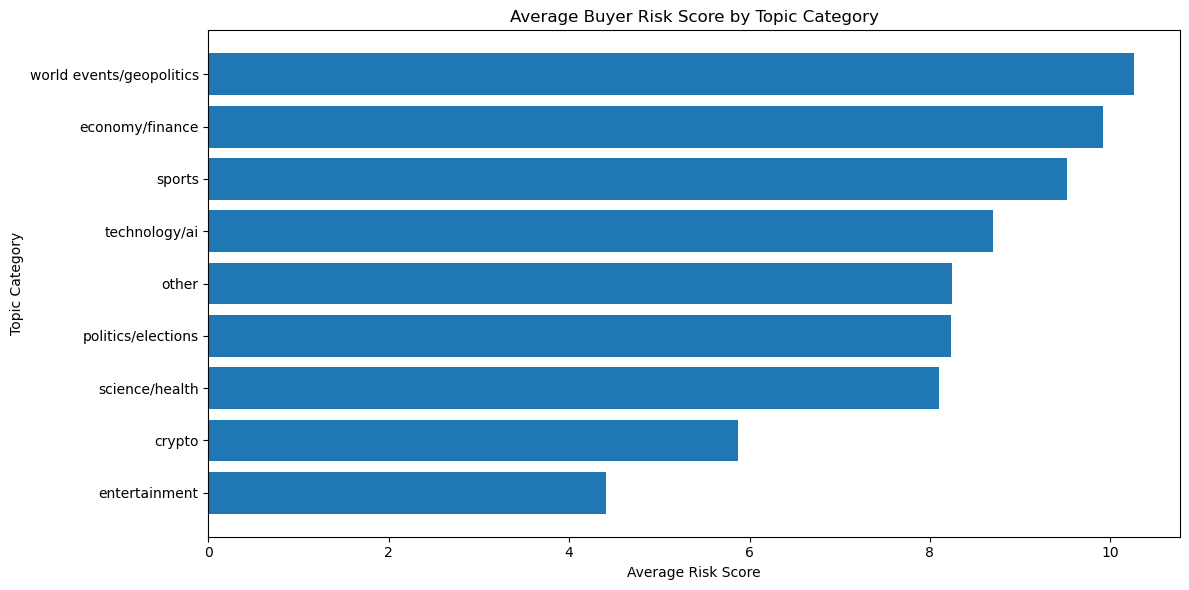

In [31]:
# Average risk score by category

plt.figure(figsize=(12, 6))

category_summary_pd_sorted = category_summary_pd.sort_values(
    "avg_risk_score",
    ascending=True
)

plt.barh(
    category_summary_pd_sorted["topic_category"],
    category_summary_pd_sorted["avg_risk_score"]
)

plt.xlabel("Average Risk Score")
plt.ylabel("Topic Category")
plt.title("Average Buyer Risk Score by Topic Category")
plt.tight_layout()
plt.show()

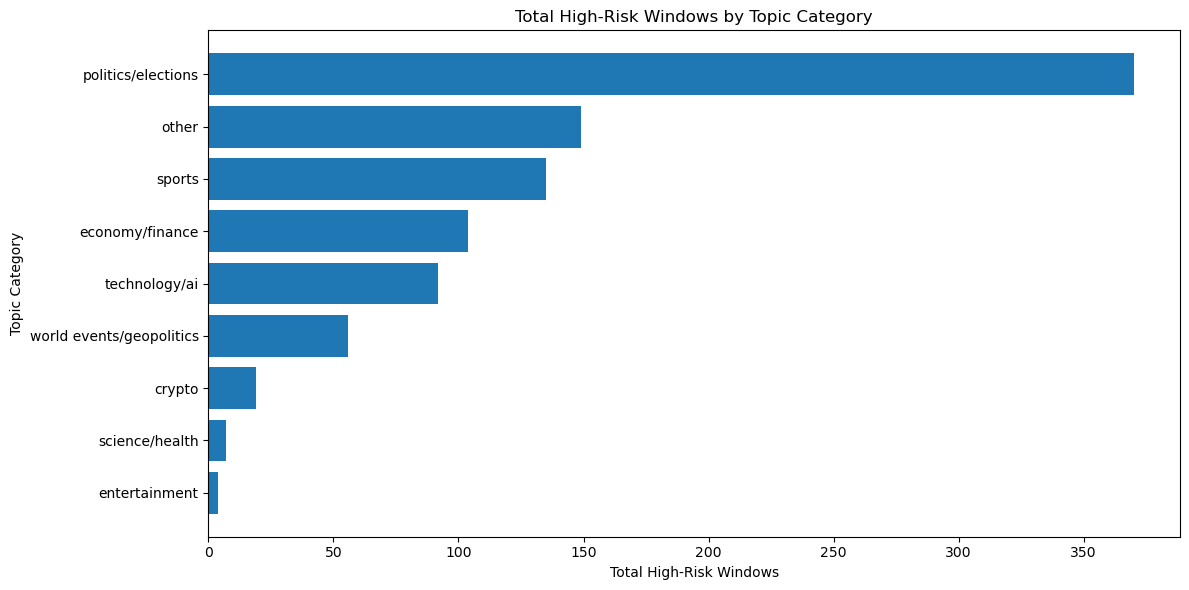

In [32]:
# Total high-risk windows by category

plt.figure(figsize=(12, 6))

category_summary_pd_sorted = category_summary_pd.sort_values(
    "total_high_risk_windows",
    ascending=True
)

plt.barh(
    category_summary_pd_sorted["topic_category"],
    category_summary_pd_sorted["total_high_risk_windows"]
)

plt.xlabel("Total High-Risk Windows")
plt.ylabel("Topic Category")
plt.title("Total High-Risk Windows by Topic Category")
plt.tight_layout()
plt.show()

In [35]:
top_markets_pd[[
    "question",
    "high_risk_window_rate",
    "avg_risk_score",
    "max_risk_score",
    "high_risk_windows",
    "window_count"
]]

,question,high_risk_window_rate,avg_risk_score,max_risk_score,high_risk_windows,window_count
0,Will the Republicans win the Oregon Senate rac...,0.000000,1.666667,5,0,24
1,Will 7-8 SpaceX Starship launches successfully...,0.000000,22.708333,40,0,24
2,Will The Bride! get the most Oscar nominations...,0.125000,21.875000,60,3,24
3,Will the New York Islanders win the 2026 NHL S...,0.000000,2.291667,5,0,24
4,Will the Indian National Congress (INC) win th...,0.000000,4.166667,5,0,24
5,Will Gold have the best performance in 2026?,0.000000,8.541667,20,0,24
6,Will the Democratic Progressive Party (DPP) wi...,0.000000,2.500000,20,0,24
7,Will Domantas Sabonis lead the NBA in assists ...,0.000000,5.000000,5,0,24
8,Another critical Cloudflare incident by March ...,0.208333,25.416667,60,5,24
9,Will Kostadin Kostadinov win the next Bulgari...,0.000000,4.583333,5,0,24


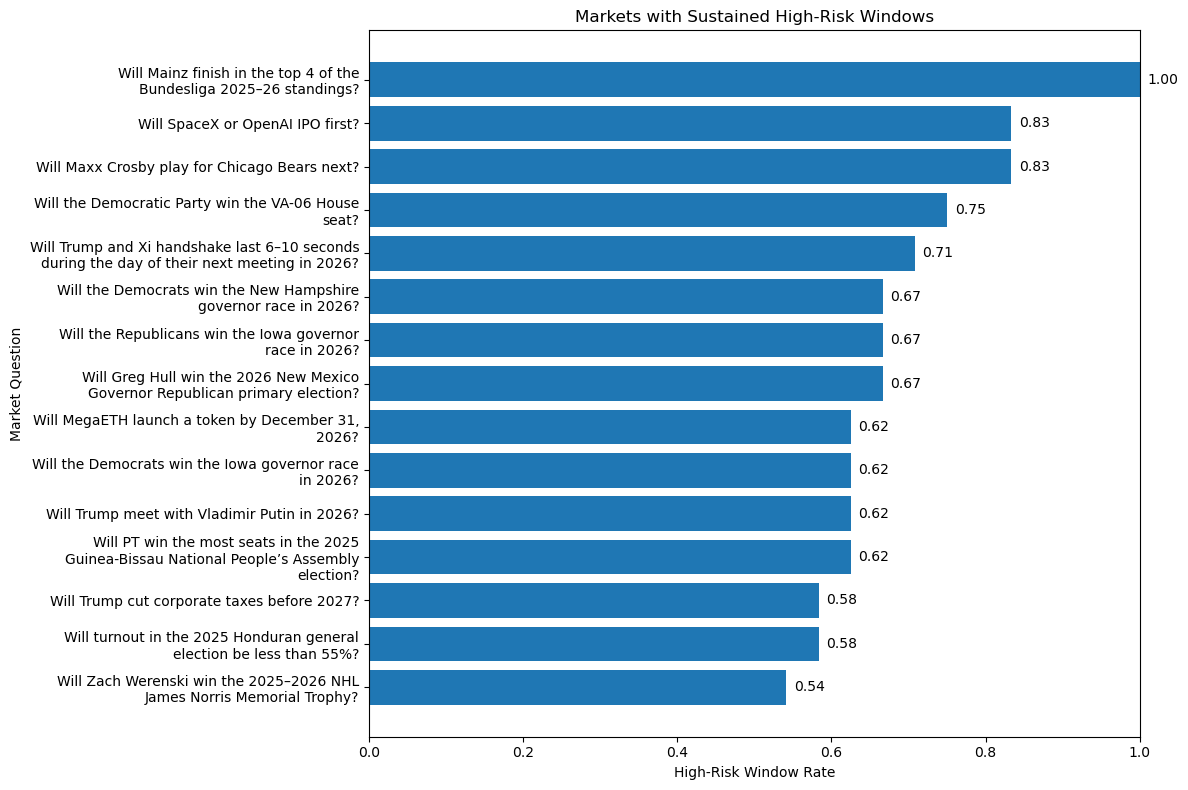

In [36]:
import textwrap
import matplotlib.pyplot as plt

plot_df = (
    df_final_market_ranking
    .filter(F.col("high_risk_window_rate") > 0)
    .orderBy(F.desc("high_risk_window_rate"), F.desc("avg_risk_score"))
    .limit(15)
    .toPandas()
)

plot_df["question_short"] = plot_df["question"].apply(
    lambda x: "\n".join(textwrap.wrap(x, width=45))
)

plot_df = plot_df.sort_values("high_risk_window_rate", ascending=True)

plt.figure(figsize=(12, 8))

plt.barh(
    plot_df["question_short"],
    plot_df["high_risk_window_rate"]
)

plt.xlabel("High-Risk Window Rate")
plt.ylabel("Market Question")
plt.title("Markets with Sustained High-Risk Windows")
plt.xlim(0, 1)

for i, value in enumerate(plot_df["high_risk_window_rate"]):
    plt.text(value + 0.01, i, f"{value:.2f}", va="center")

plt.tight_layout()
plt.show()

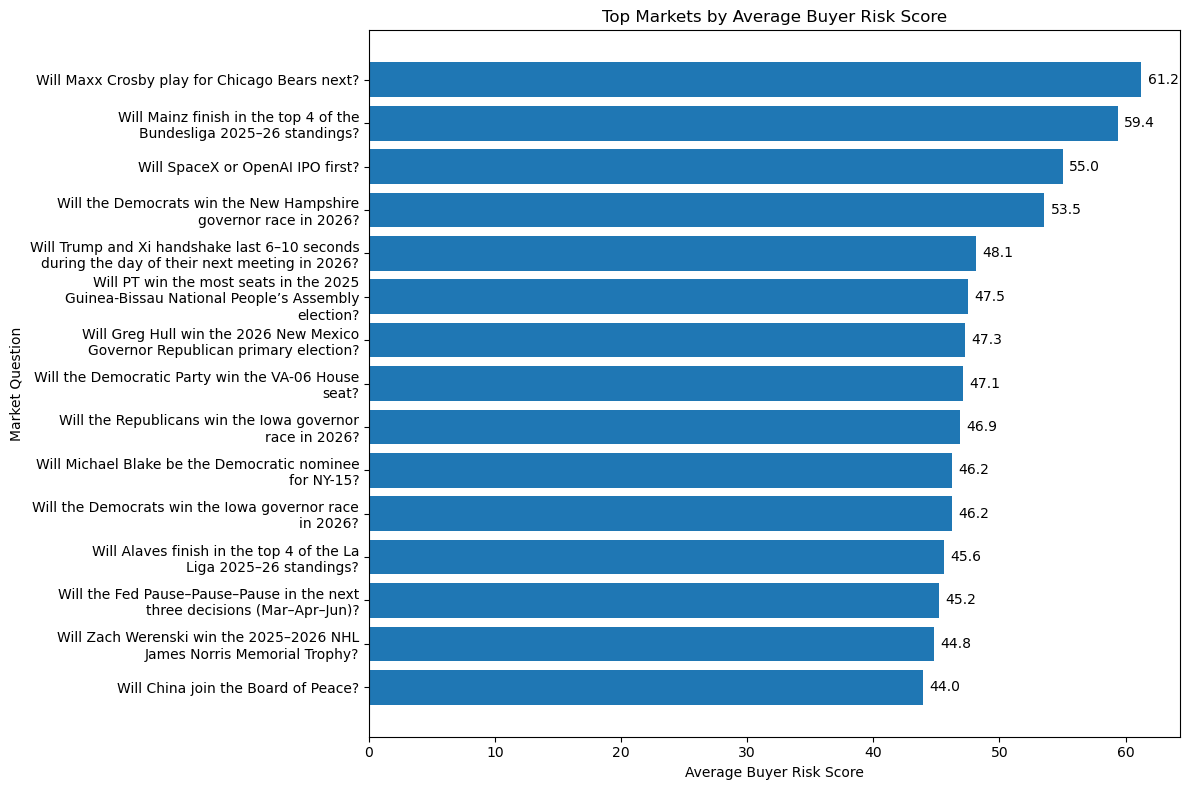

In [38]:
plot_df = (
    df_final_market_ranking
    .orderBy(F.desc("avg_risk_score"))
    .limit(15)
    .toPandas()
)

plot_df["question_short"] = plot_df["question"].apply(
    lambda x: "\n".join(textwrap.wrap(x, width=45))
)

plot_df = plot_df.sort_values("avg_risk_score", ascending=True)

plt.figure(figsize=(12, 8))

plt.barh(
    plot_df["question_short"],
    plot_df["avg_risk_score"]
)

plt.xlabel("Average Buyer Risk Score")
plt.ylabel("Market Question")
plt.title("Top Markets by Average Buyer Risk Score")

for i, value in enumerate(plot_df["avg_risk_score"]):
    plt.text(value + 0.5, i, f"{value:.1f}", va="center")

plt.tight_layout()
plt.show()

## 16. Save Final Outputs

This section saves the final outputs and a run manifest.

### Outputs saved

- final market ranking as Parquet
- final category summary as Parquet
- sample market ranking as CSV folder
- category summary as CSV folder
- `manifest.json` describing paths, run name, and saved outputs


In [34]:
# Safe final output save cell
# Uses MARKET_SCORES_EXPLAINED_PATH, which exists in this notebook.
# Avoids reading from and overwriting the same Parquet path.

import os
import shutil
import json
from datetime import datetime

def good_parquet(path):
    """Check if a Spark parquet folder looks complete."""
    if not os.path.isdir(path):
        return False
    if not os.path.exists(os.path.join(path, "_SUCCESS")):
        return False
    return any(name.endswith(".parquet") for name in os.listdir(path))

def safe_replace_parquet(df, final_path, temp_suffix="_tmp_write", partitions=8):
    """
    Write to a temp folder first, then replace the final folder.
    This prevents Spark from deleting a folder while it is still reading from it.
    """
    temp_path = final_path + temp_suffix

    if os.path.exists(temp_path):
        shutil.rmtree(temp_path)

    (
        df.repartition(partitions)
        .write
        .mode("overwrite")
        .parquet(temp_path)
    )

    if os.path.exists(final_path):
        shutil.rmtree(final_path)

    os.rename(temp_path, final_path)
    print(f"Saved: {final_path}")

# Clear Spark cache / stale file references
spark.catalog.clearCache()

os.makedirs(EXPORT_PATH, exist_ok=True)

# Rebuild final tables from the explained market scores checkpoint.
# Do NOT load from FINAL_MARKET_RANKING_PATH because that folder may be corrupted.
if good_parquet(MARKET_SCORES_EXPLAINED_PATH):
    df_market_scores_explained = spark.read.parquet(MARKET_SCORES_EXPLAINED_PATH)

elif "df_market_scores_explained" not in globals():
    raise RuntimeError(
        "df_market_scores_explained is missing and MARKET_SCORES_EXPLAINED_PATH is not available. "
        "Rerun the main risk driver / explained scores section first."
    )

df_final_market_ranking = (
    df_market_scores_explained
    .select(
        "market_id",
        "question",
        "topic_category",
        "window_count",
        "avg_risk_score",
        "max_risk_score",
        "high_risk_windows",
        "very_high_risk_windows",
        "high_risk_window_rate",
        "overall_avg_spread",
        "max_price_range",
        "avg_imbalance_score",
        "total_anomaly_count",
        "main_risk_driver"
    )
    .orderBy(
        F.desc("high_risk_window_rate"),
        F.desc("avg_risk_score"),
        F.desc("max_risk_score"),
        F.desc("total_anomaly_count")
    )
)

df_final_category_summary = (
    df_market_scores_explained
    .groupBy("topic_category")
    .agg(
        F.count("*").alias("market_count"),
        F.avg("avg_risk_score").alias("avg_risk_score"),
        F.avg("max_risk_score").alias("avg_max_risk_score"),
        F.sum("high_risk_windows").alias("total_high_risk_windows"),
        F.sum("very_high_risk_windows").alias("total_very_high_risk_windows"),
        F.avg("high_risk_window_rate").alias("avg_high_risk_window_rate"),
        F.avg("overall_avg_spread").alias("avg_spread"),
        F.avg("avg_imbalance_score").alias("avg_imbalance_score")
    )
    .orderBy(F.desc("avg_risk_score"))
)

# Safely write final Parquet outputs
safe_replace_parquet(
    df_final_market_ranking,
    FINAL_MARKET_RANKING_PATH,
    partitions=8
)

safe_replace_parquet(
    df_final_category_summary,
    FINAL_CATEGORY_SUMMARY_PATH,
    partitions=1
)

# Save CSV outputs using Spark instead of toPandas
market_csv_path = os.path.join(EXPORT_PATH, "final_market_ranking_sample_csv")
category_csv_path = os.path.join(EXPORT_PATH, "final_category_summary_csv")

for p in [market_csv_path, category_csv_path]:
    if os.path.exists(p):
        shutil.rmtree(p)

(
    df_final_market_ranking
    .limit(1000)
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(market_csv_path)
)

(
    df_final_category_summary
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(category_csv_path)
)

manifest = {
    "run_name": RUN_NAME,
    "created_at": datetime.now().isoformat(),
    "labels_path": LABELS_PATH,
    "orderbook_path": ORDERBOOK_PATH,
    "run_path": RUN_PATH,
    "silver_path": SILVER_PATH,
    "gold_path": GOLD_PATH,
    "export_path": EXPORT_PATH,
    "force_rebuild": FORCE_REBUILD,
    "saved_tables": {
        "ob_labeled_clean": OB_LABELED_CLEAN_PATH,
        "market_window_features": FEATURES_PATH,
        "scored_market_windows": SCORED_WINDOWS_PATH,
        "market_scores_explained": MARKET_SCORES_EXPLAINED_PATH,
        "final_market_ranking": FINAL_MARKET_RANKING_PATH,
        "final_category_summary": FINAL_CATEGORY_SUMMARY_PATH,
        "final_market_ranking_sample_csv_folder": market_csv_path,
        "final_category_summary_csv_folder": category_csv_path,
    },
    "notes": "Resumable MVP rule-based buyer risk scoring pipeline using 1-hour market windows."
}

with open(os.path.join(RUN_PATH, "manifest.json"), "w") as f:
    json.dump(manifest, f, indent=2)

print("Outputs saved.")
print("Run path:", RUN_PATH)
print("Export path:", EXPORT_PATH)

checkpoint_status()

Saved: /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/gold/final_market_ranking
Saved: /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/gold/final_category_summary
Outputs saved.
Run path: /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp
Export path: /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/exports
ob_labeled_clean             FOUND - /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/silver/ob_labeled_clean
market_activity              FOUND - /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/silver/market_activity
active_markets               FOUND - /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2

## Limitations

1. **No fraud labels.** The dataset does not provide confirmed fraud/manipulation labels, so the notebook uses rule-based anomaly scoring rather than supervised fraud classification.
2. **No proof of intent.** The score identifies abnormal behavior, not trader intent or legal manipulation.
3. **Partial metadata coverage.** Only orderbook markets that successfully join to the labels table are used for interpretable market-level reporting.
4. **Resource-constrained MVP.** The notebook includes safe-mode processing and checkpointing to handle local Spark limitations. In larger Spark infrastructure, the same logic can be scaled to more markets and more orderbook days.
5. **Keyword-based categories.** Topic categories are created from market question text using rules because the original category field is mostly blank.
6. **Limited orderbook depth.** The MVP uses available top-level orderbook fields and change events. Full spoofing/layering detection would require deeper book-level data and order-cancellation behavior.
7. **Heuristic weights.** The Buyer Risk Score weights are explainable design choices for the MVP. They should be calibrated with expert review, labeled events, or historical backtesting in future versions.

## Future Improvements

1. Process multiple days of orderbook data.
2. Add unsupervised machine learning such as clustering or Isolation Forest after the rule-based MVP is stable.
3. Replace keyword topic rules with a stronger NLP classifier.
4. Validate high-risk windows against external news or major event timestamps.
5. Add full orderbook depth features if available.
6. Calibrate score weights using expert review or known abnormal market examples.
7. Build a simple dashboard for buyer-facing review.

## Sources and Method Support

The scoring logic is an original, explainable MVP design. The sources below support the broader methodological basis: anomaly detection, financial fraud/risk screening, transaction-pattern analysis, explainability, and AI use in finance.

1. Deepak. (2025). *AI in Finance: Fraud Detection, Algorithmic Trading, and Risk Assessment*. International Journal of Applied and Behavioural Sciences, 02(02), 37–48. DOI: https://doi.org/10.70388/ijabs250135.
2. Bolton, R. J., & Hand, D. J. (2002). Statistical fraud detection: A review. *Statistical Science*, 17(3), 235–255. https://doi.org/10.1214/ss/1042727940
3. Ngai, E. W. T., Hu, Y., Wong, Y. H., Chen, Y., & Sun, X. (2011). The application of data mining techniques in financial fraud detection: A classification framework and an academic review of literature. *Decision Support Systems*, 50(3), 559–569. https://doi.org/10.1016/j.dss.2010.08.006
4. West, J., & Bhattacharya, M. (2016). Intelligent financial fraud detection: A comprehensive review. *Computers & Security*, 57, 47–66. https://doi.org/10.1016/j.cose.2015.09.005
5. Jain, V., Kumar, R., & Sharma, D. (2022). Financial fraud detection using ensemble learning. *Expert Systems with Applications*, 193, Article 116421. https://doi.org/10.1016/j.eswa.2021.116421
6. Bhatia, M., & Kumar, A. (2020). Artificial intelligence in compliance and risk management in the financial sector. *Journal of Financial Regulation and Compliance*, 28(3), 313–328. https://doi.org/10.1108/JFRC-12-2019-0154
7. Treleaven, P., Galas, M., & Lalchand, V. (2013). Algorithmic trading and machine learning. *The Computer Journal*, 56(5), 491–510. https://doi.org/10.1093/comjnl/bxt067
8. Goodell, J. W., Huynh, T. L. D., & Vo, X. V. (2021). Risks and returns of cryptocurrency: Evidence from a new dataset. *Journal of Risk and Financial Management*, 14(6), 252. https://doi.org/10.3390/jrfm14060252